In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
longi = pd.read_csv('oasis_longitudinal.csv')
cross = pd.read_csv('oasis_cross-sectional.csv')


In [3]:
display(longi.head())
display(cross.head())

,Subject ID,MRI ID,Group,Visit,MR Delay,Sex,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,1,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,1,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,1,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,1,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,1,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


,ID,Sex,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,0,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,0,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,0,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,1,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,1,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [4]:
print("Longi:", longi.shape)
print("Cross:", cross.shape)

Longi: (373, 15)
Cross: (436, 12)


In [5]:
longi.info()


<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    str    
 1   MRI ID      373 non-null    str    
 2   Group       373 non-null    str    
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   Sex         373 non-null    int64  
 6   Hand        373 non-null    str    
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(6), str(4)
memory usage: 43.8 KB


In [6]:
cross.info()

<class 'pandas.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    str    
 1   Sex     436 non-null    int64  
 2   Hand    436 non-null    str    
 3   Age     436 non-null    int64  
 4   Educ    235 non-null    float64
 5   SES     216 non-null    float64
 6   MMSE    235 non-null    float64
 7   CDR     235 non-null    float64
 8   eTIV    436 non-null    int64  
 9   nWBV    436 non-null    float64
 10  ASF     436 non-null    float64
 11  Delay   20 non-null     float64
dtypes: float64(7), int64(3), str(2)
memory usage: 41.0 KB


In [7]:
"""
¿Desde qué edad es vuelve común la demencia/alzheimer?
¿Qué relaciones existen entre los tamaños craneles y cerebrales con la demencia/alzheimer?
¿Existe una relación entre el nivel socioeconómico y la demencia/alzheimer?
"""

'\n¿Desde qué edad es vuelve común la demencia/alzheimer?\n¿Qué relaciones existen entre los tamaños craneles y cerebrales con la demencia/alzheimer?\n¿Existe una relación entre el nivel socioeconómico y la demencia/alzheimer?\n'

In [8]:
longi.isna().sum()

Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
Sex            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

In [9]:
cross.isna().sum()

ID         0
Sex        0
Hand       0
Age        0
Educ     201
SES      220
MMSE     201
CDR      201
eTIV       0
nWBV       0
ASF        0
Delay    416
dtype: int64

In [10]:
cross = cross.drop(columns='Delay')

In [11]:
longi['SES'] = longi['SES'].fillna(longi['SES'].median())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
cross['SES'] = cross['SES'].fillna(cross['SES'].median())
cross['MMSE'] = cross['MMSE'].fillna(cross['MMSE'].median())
cross['Educ'] = cross['Educ'].fillna(cross['Educ'].median())
cross['CDR'] = cross['CDR'].fillna(cross['CDR'].median())
"""
He decidido rellenar los valores faltantes de SES y MMSE con la mediana de cada columna, ya que ambos no tienen una cantidad excesiva de 
valores faltantes. Esto permitirá mantener la integridad del dataset sin eliminar filas completas, lo que resultaría en la pérdida de 
información valiosa para la respuesta de las preguntas ya planteadas.
"""


'\nHe decidido rellenar los valores faltantes de SES y MMSE con la mediana de cada columna, ya que ambos no tienen una cantidad excesiva de \nvalores faltantes. Esto permitirá mantener la integridad del dataset sin eliminar filas completas, lo que resultaría en la pérdida de \ninformación valiosa para la respuesta de las preguntas ya planteadas.\n'

In [12]:
print("Total de filas duplicadas(longi):", longi.duplicated().sum())
print("Total de filas duplicadas(cross):", cross.duplicated().sum())

Total de filas duplicadas(longi): 0
Total de filas duplicadas(cross): 0


In [13]:
longi.drop_duplicates(inplace=True)
cross.drop_duplicates(inplace=True)

In [14]:
longi.describe()

,Visit,MR Delay,Sex,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,0.428954,77.013405,14.597855,2.436997,27.351206,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,0.495592,7.640957,2.876339,1.109307,3.675329,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,0.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,1.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,1.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


In [15]:
cross.describe()

,Sex,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF
count,436.000000,436.000000,436.000000,436.000000,436.000000,436.00000,436.000000,436.000000,436.000000
mean,0.385321,51.357798,3.096330,2.243119,27.956422,0.15367,1481.919725,0.791670,1.198894
std,0.487230,25.269862,0.966037,0.825219,2.878446,0.31515,158.740866,0.059937,0.128682
min,0.000000,18.000000,1.000000,1.000000,14.000000,0.00000,1123.000000,0.644000,0.881000
25%,0.000000,23.000000,3.000000,2.000000,28.000000,0.00000,1367.750000,0.742750,1.111750
50%,0.000000,54.000000,3.000000,2.000000,29.000000,0.00000,1475.500000,0.809000,1.190000
75%,1.000000,74.000000,3.000000,2.000000,29.000000,0.00000,1579.250000,0.842000,1.284250
max,1.000000,96.000000,5.000000,5.000000,30.000000,2.00000,1992.000000,0.893000,1.563000


In [16]:
columnas_comunes = ['ID', 'Sex', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
longi_renamed = longi.rename(columns={'EDUC': 'Educ', 'Subject ID': 'ID'})
df = pd.concat([cross[columnas_comunes], longi_renamed[columnas_comunes]], ignore_index=True)

In [17]:
nor = 0
mleve = 0
leve = 0
mode = 0

for cdr in df['CDR']:
    if cdr == 0.5:
        mleve += 1
    elif cdr == 1.0:
        leve +=1
    elif cdr == 2.0:
        mode +=1
    else:
        nor += 1

print(f'normal: {nor}, muy leve: {mleve}, leve: {leve}, moderado: {mode}')


normal: 542, muy leve: 193, leve: 69, moderado: 5


In [18]:
nor = 0
mleve = 0
leve = 0
mode = 0

for cdr in longi['CDR']:
    if cdr == 0.5:
        mleve += 1
    elif cdr == 1.0:
        leve +=1
    elif cdr == 2.0:
        mode +=1
    else:
        nor += 1

print(f'normal: {nor}, muy leve: {mleve}, leve: {leve}, moderado: {mode}')

normal: 206, muy leve: 123, leve: 41, moderado: 3


In [19]:
nor = 0
mleve = 0
leve = 0
mode = 0

for cdr in cross['CDR']:
    if cdr == 0.5:
        mleve += 1
    elif cdr == 1.0:
        leve +=1
    elif cdr == 2.0:
        mode +=1
    else:
        nor += 1

print(f'normal: {nor}, muy leve: {mleve}, leve: {leve}, moderado: {mode}')

normal: 336, muy leve: 70, leve: 28, moderado: 2


In [20]:
df.describe()

,Sex,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF
count,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000
mean,0.405439,63.186650,8.399258,2.332509,27.677379,0.216934,1484.782447,0.763037,1.197311
std,0.491280,23.117511,6.101051,0.970834,3.281888,0.350350,166.911689,0.059401,0.133031
min,0.000000,18.000000,1.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,0.000000,49.000000,3.000000,2.000000,27.000000,0.000000,1361.000000,0.715000,1.108000
50%,0.000000,72.000000,5.000000,2.000000,29.000000,0.000000,1475.000000,0.754000,1.190000
75%,1.000000,80.000000,14.000000,3.000000,29.000000,0.500000,1583.000000,0.817000,1.290000
max,1.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.893000,1.587000


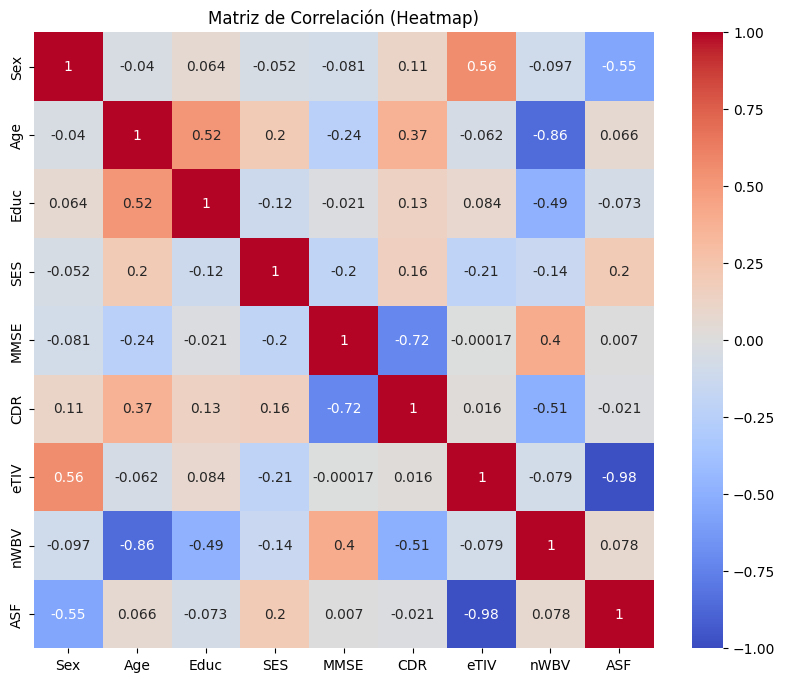

In [21]:
plt.figure(figsize=(10, 8))
# df.corr() calcula la correlación. annot=True dibuja el número dentro del cuadro.
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Heatmap)')
plt.show()

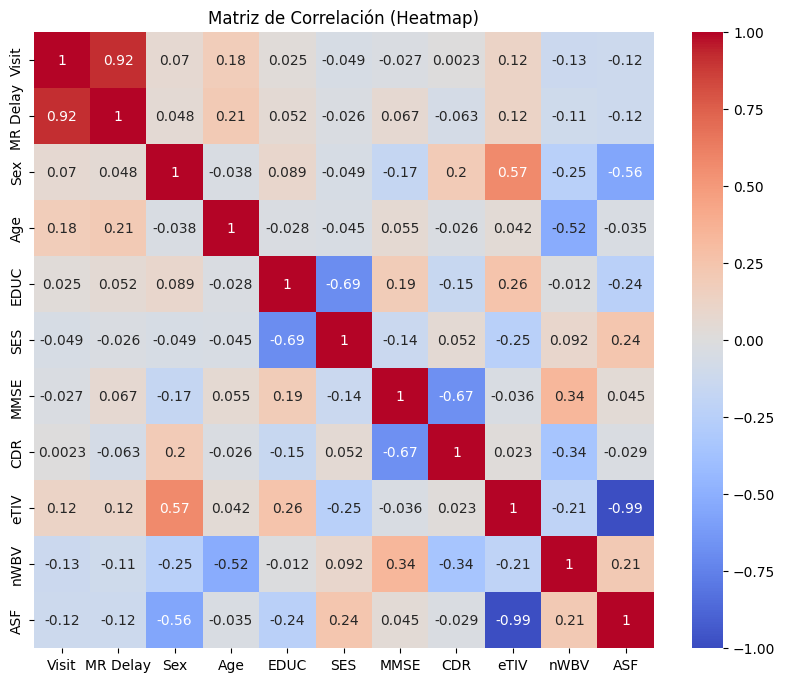

In [22]:
plt.figure(figsize=(10, 8))
# df.corr() calcula la correlación. annot=True dibuja el número dentro del cuadro.
sns.heatmap(longi.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Heatmap)')
plt.show()

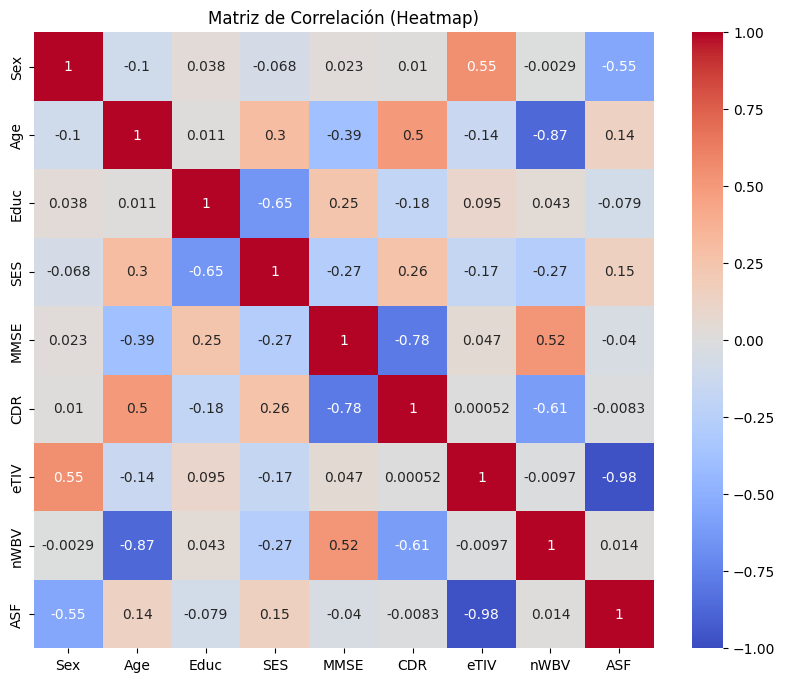

In [23]:
plt.figure(figsize=(10, 8))
# df.corr() calcula la correlación. annot=True dibuja el número dentro del cuadro.
sns.heatmap(cross.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación (Heatmap)')
plt.show()

Sesgo (Skewness): 0.20615300170743314
Curtosis: -1.0696748363200033


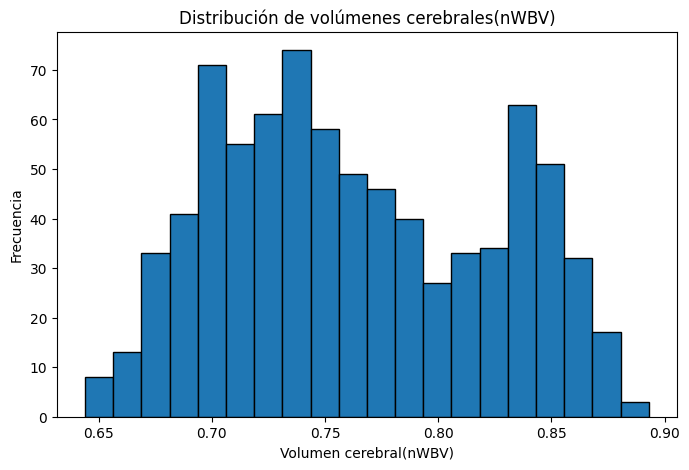

In [24]:
sesgo = stats.skew(df['nWBV'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(df['nWBV'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
df['nWBV'].plot(kind='hist', bins=20,
edgecolor='black')
plt.title('Distribución de volúmenes cerebrales(nWBV)')
plt.xlabel('Volumen cerebral(nWBV)')
plt.ylabel('Frecuencia')
plt.show()

Sesgo (Skewness): 1.737065068940469
Curtosis: 3.491245228731553


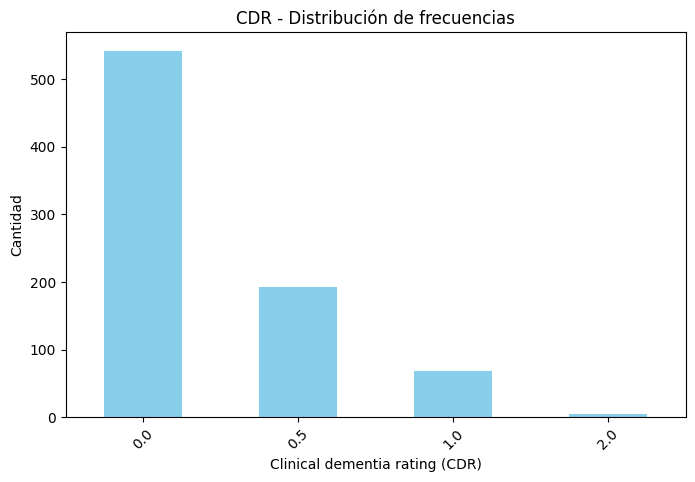

In [25]:
sesgo = stats.skew(df['CDR'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(df['CDR'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))

df['CDR'].value_counts().plot(kind='bar',
color='skyblue')
plt.title('CDR - Distribución de frecuencias')
plt.xlabel('Clinical dementia rating (CDR)')
plt.ylabel('Cantidad')
plt.xticks(rotation=45) # Rota el texto del eje X si es muy largo
plt.show()


Sesgo (Skewness): -2.5529316436055223
Curtosis: 8.056353890689886


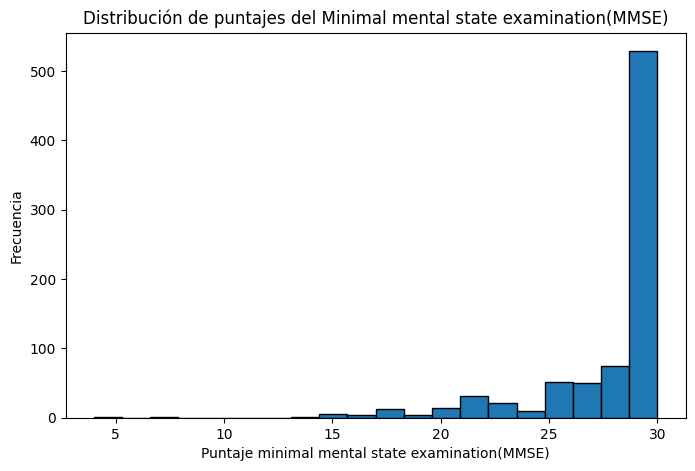

In [26]:
sesgo = stats.skew(df['MMSE'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(df['MMSE'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
df['MMSE'].plot(kind='hist', bins=20,
edgecolor='black')
plt.title('Distribución de puntajes del Minimal mental state examination(MMSE)')
plt.xlabel('Puntaje minimal mental state examination(MMSE)')
plt.ylabel('Frecuencia')
plt.show()

Sesgo (Skewness): -0.8692714329349748
Curtosis: -0.6841161274681902


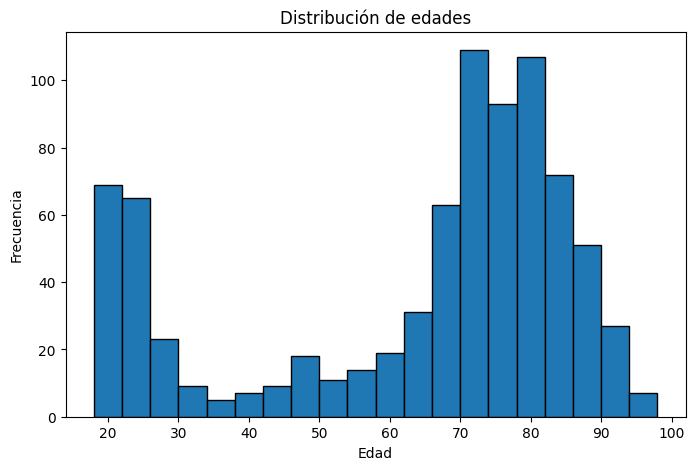

In [27]:
sesgo = stats.skew(df['Age'].dropna())
print(f"Sesgo (Skewness): {sesgo}")
curtosis = stats.kurtosis(df['Age'].dropna())
print(f"Curtosis: {curtosis}")

plt.figure(figsize=(8, 5))
df['Age'].plot(kind='hist', bins=20,
edgecolor='black')
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

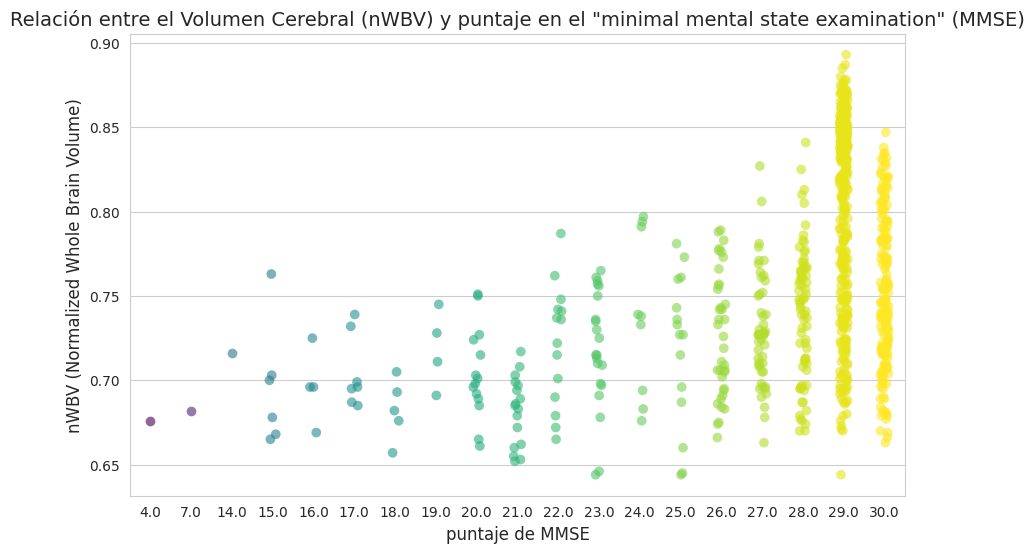

In [28]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.stripplot(x='MMSE', y='nWBV', data=df, 
              hue='MMSE', legend=False, palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre el Volumen Cerebral (nWBV) y puntaje en el "minimal mental state examination" (MMSE)', fontsize=14)
plt.xlabel('puntaje de MMSE', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()


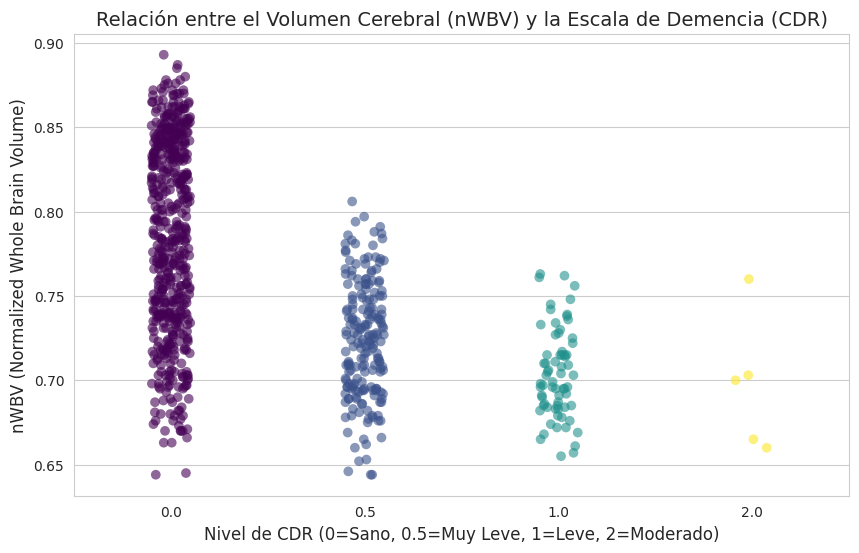

In [29]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.stripplot(x='CDR', y='nWBV', data=df, 
              hue='CDR', legend=False,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre el Volumen Cerebral (nWBV) y la Escala de Demencia (CDR)', fontsize=14)
plt.xlabel('Nivel de CDR (0=Sano, 0.5=Muy Leve, 1=Leve, 2=Moderado)', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

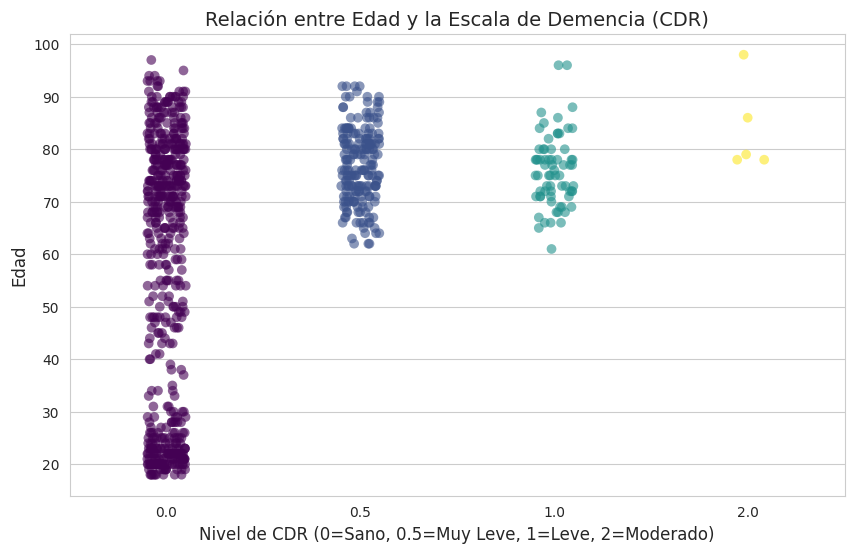

In [30]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='CDR', y='Age', data=df, 
              hue='CDR', legend=False, palette='viridis', 
              alpha=0.6, size=7, jitter=True)

plt.title('Relación entre Edad y la Escala de Demencia (CDR)', fontsize=14)
plt.xlabel('Nivel de CDR (0=Sano, 0.5=Muy Leve, 1=Leve, 2=Moderado)', fontsize=12)
plt.ylabel('Edad', fontsize=12)

plt.show()

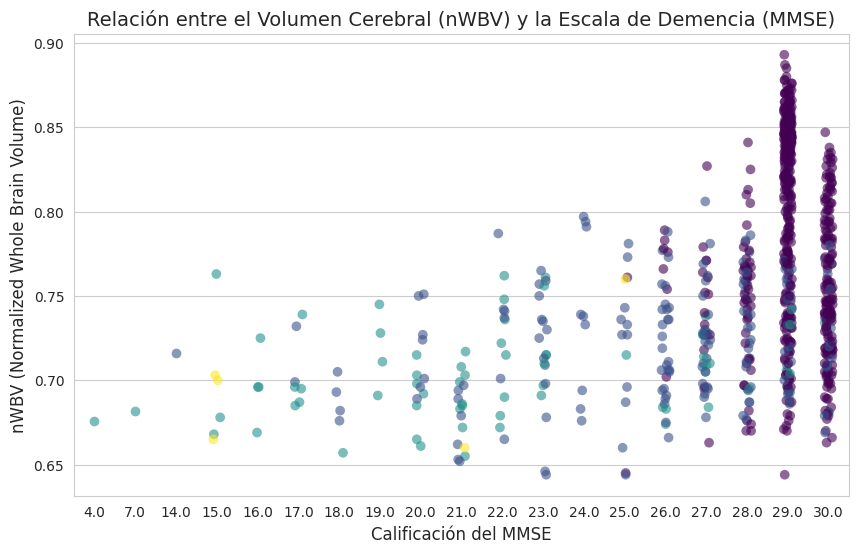

In [31]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.stripplot(x='MMSE', y='nWBV', data=df, 
              hue='CDR', legend=False,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre el Volumen Cerebral (nWBV) y la Escala de Demencia (MMSE)', fontsize=14)
plt.xlabel('Calificación del MMSE', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

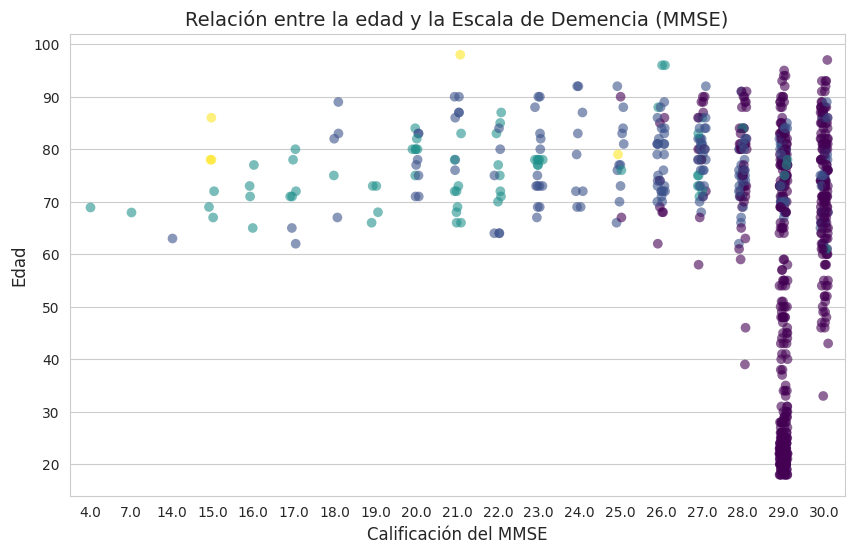

In [32]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.stripplot(x='MMSE', y='Age', data=df, 
              hue='CDR', legend=False,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre la edad y la Escala de Demencia (MMSE)', fontsize=14)
plt.xlabel('Calificación del MMSE', fontsize=12)
plt.ylabel('Edad', fontsize=12)

plt.show()

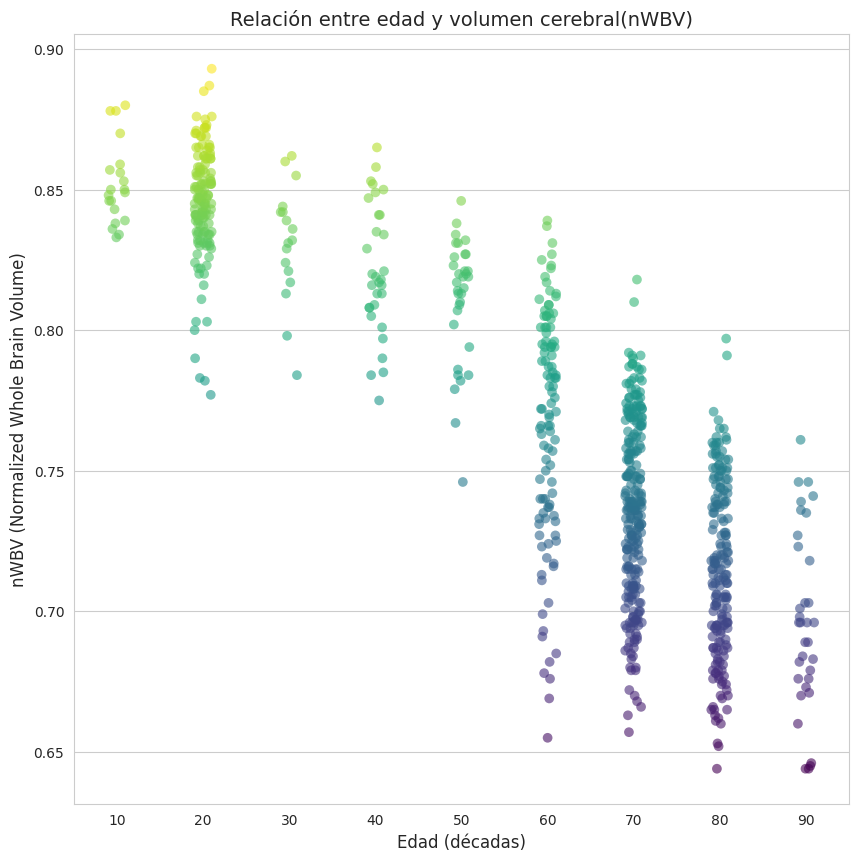

In [33]:
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")

df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='Decade', y='nWBV', data=df, 
              hue='nWBV', legend=False,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre edad y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('Edad (décadas)', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

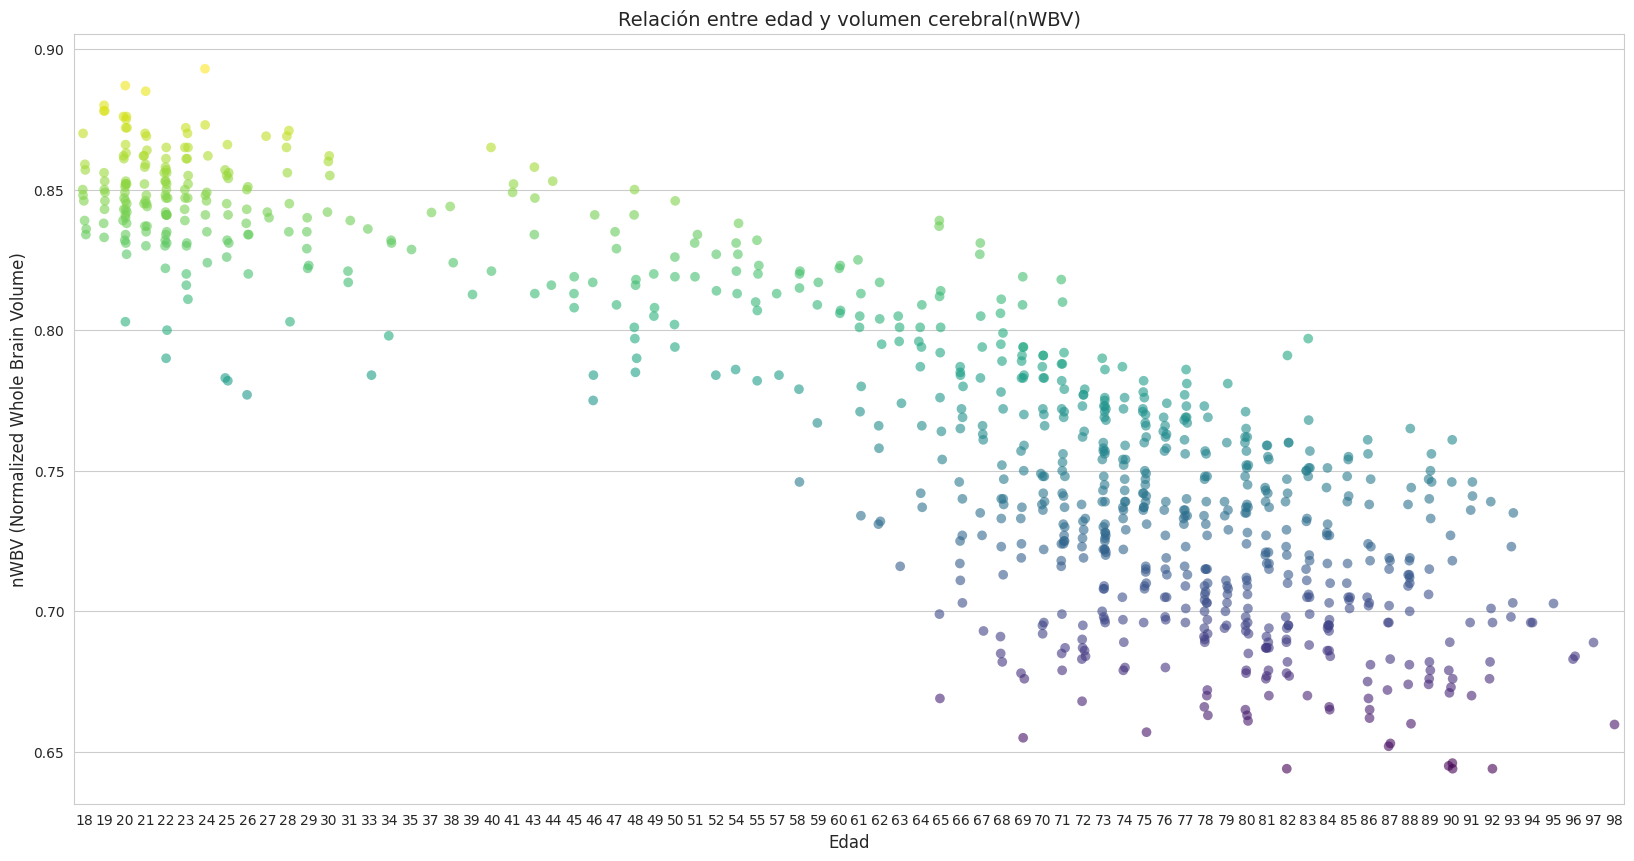

In [34]:
plt.figure(figsize=(20, 10))
sns.set_style("whitegrid")

df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='Age', y='nWBV', data=df, 
              hue='nWBV', legend=False,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre edad y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

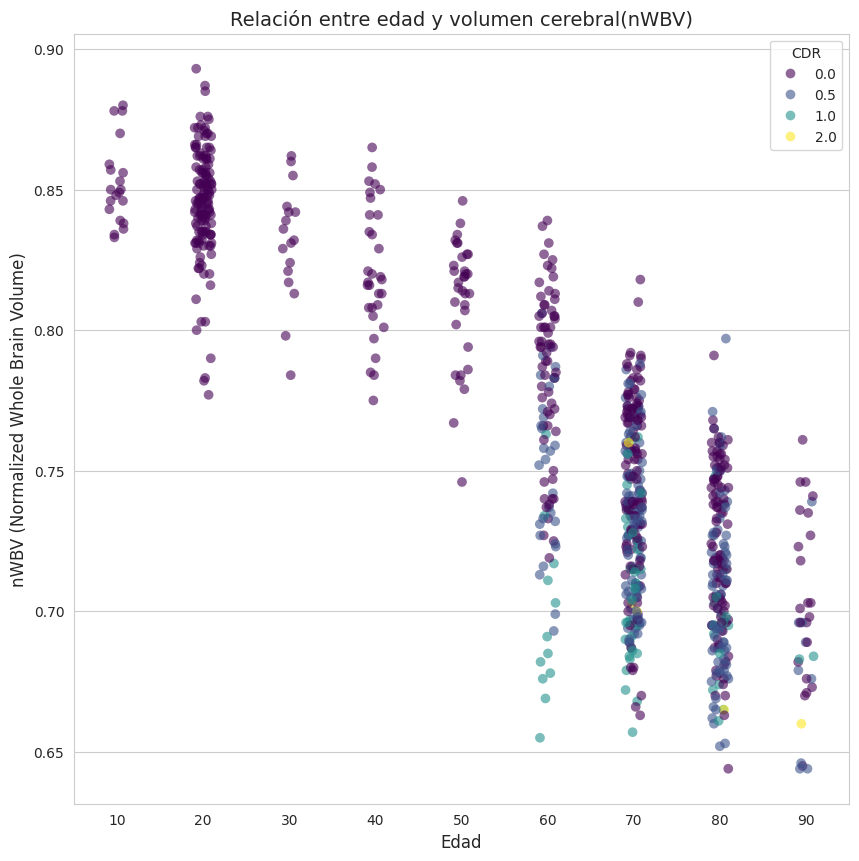

In [35]:
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")

df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='Decade', y='nWBV', data=df, 
              hue='CDR', legend=True,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre edad y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

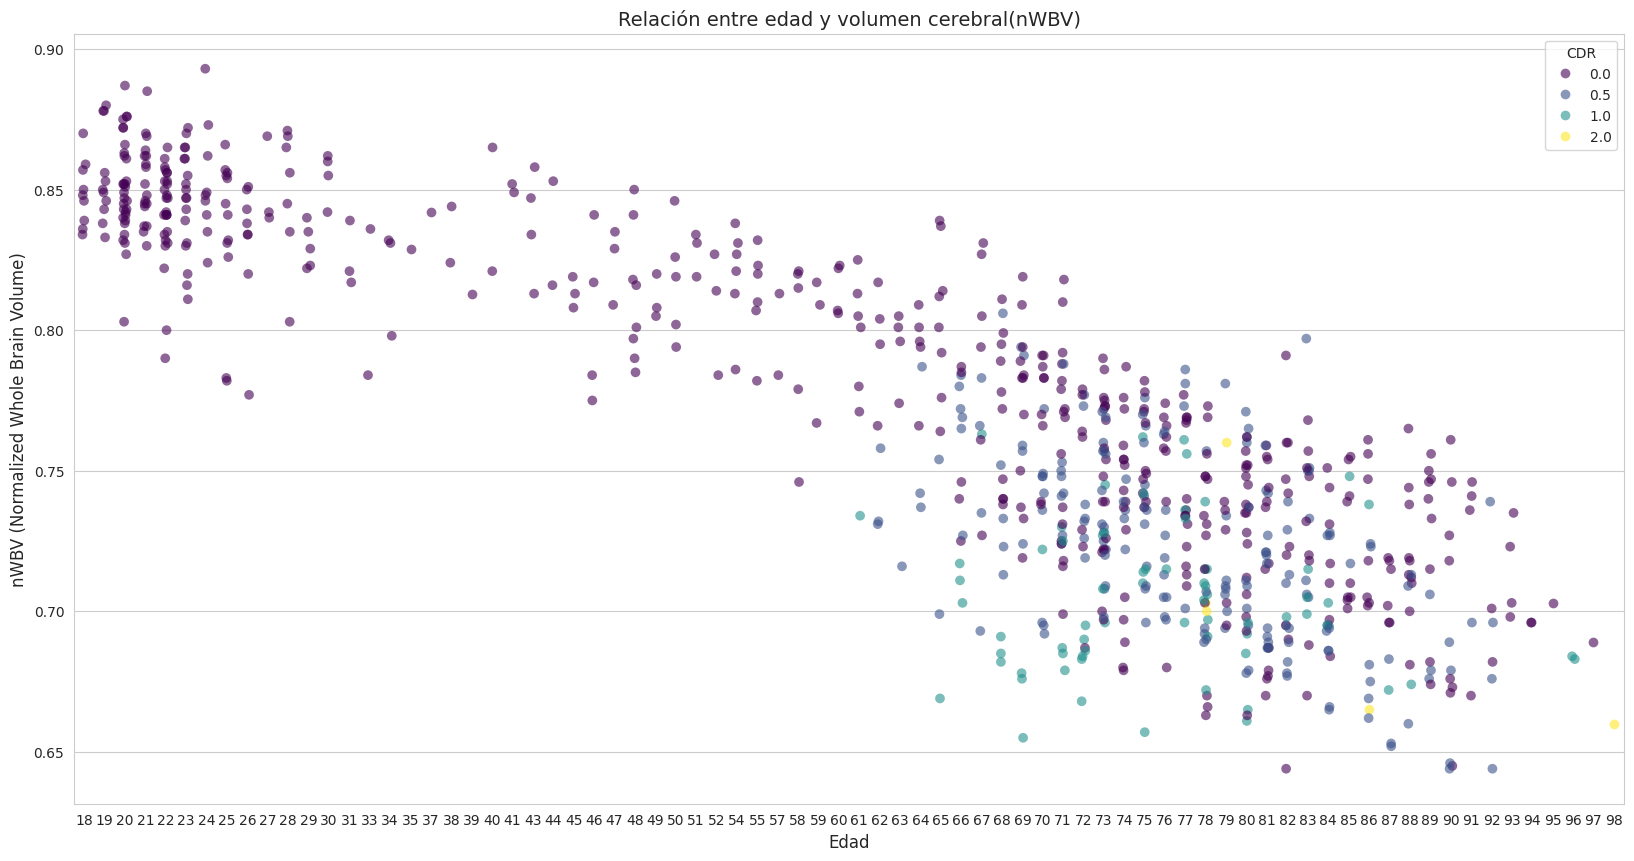

In [36]:
plt.figure(figsize=(20, 10))
sns.set_style("whitegrid")

df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='Age', y='nWBV', data=df, 
              hue='CDR', legend=True,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre edad y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

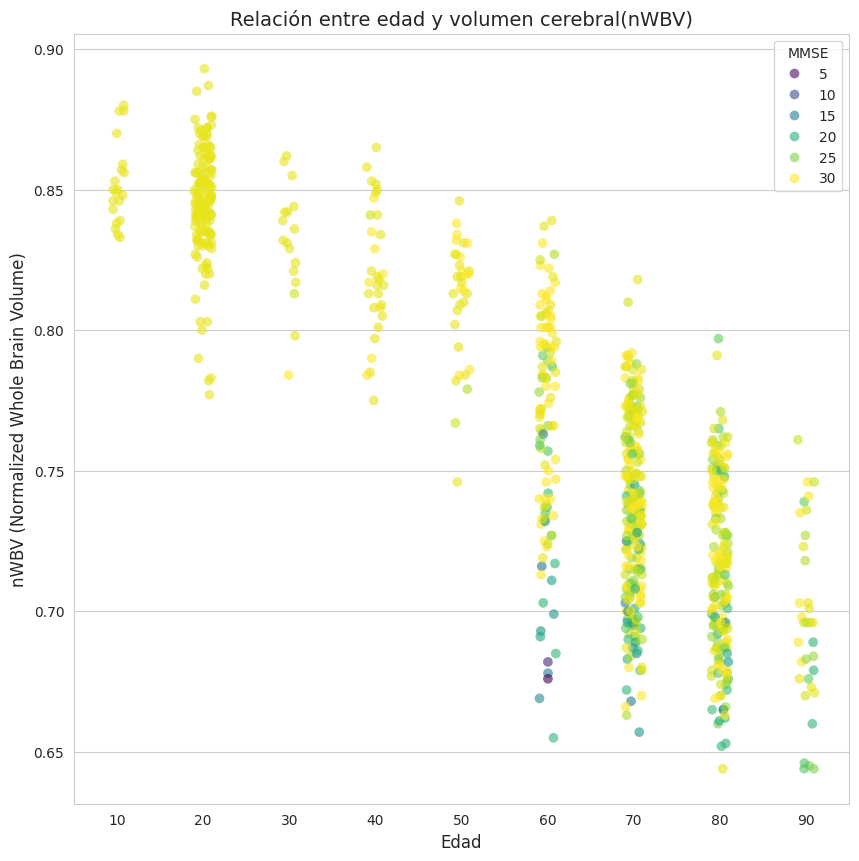

In [37]:
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")

df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='Decade', y='nWBV', data=df, 
              hue='MMSE', legend=True,palette='viridis',  
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre edad y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

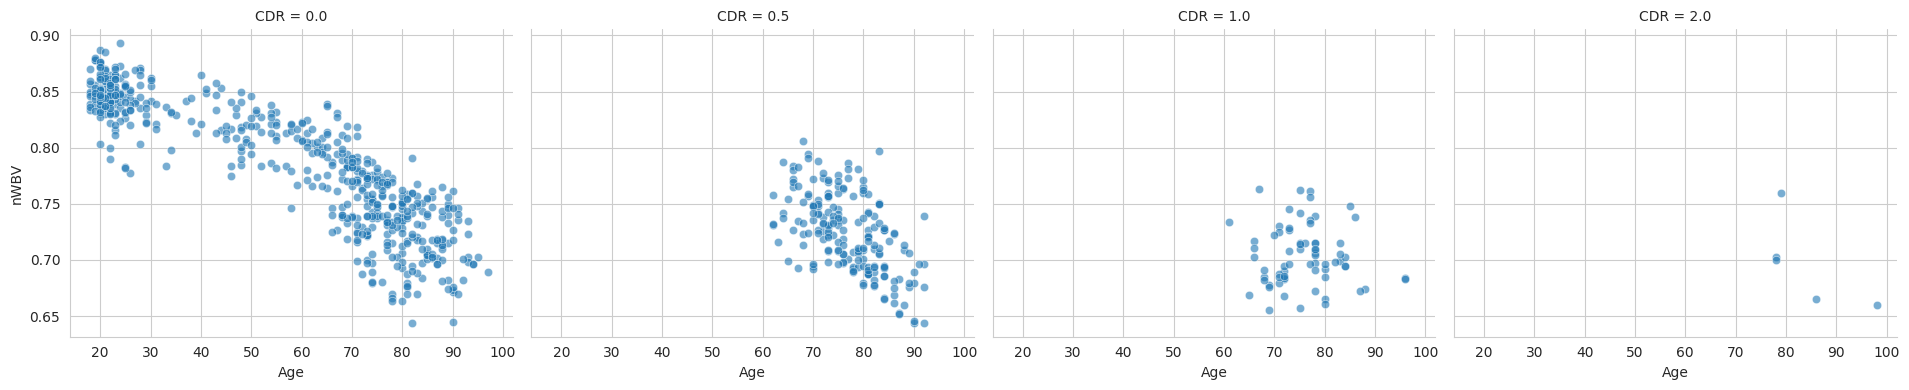

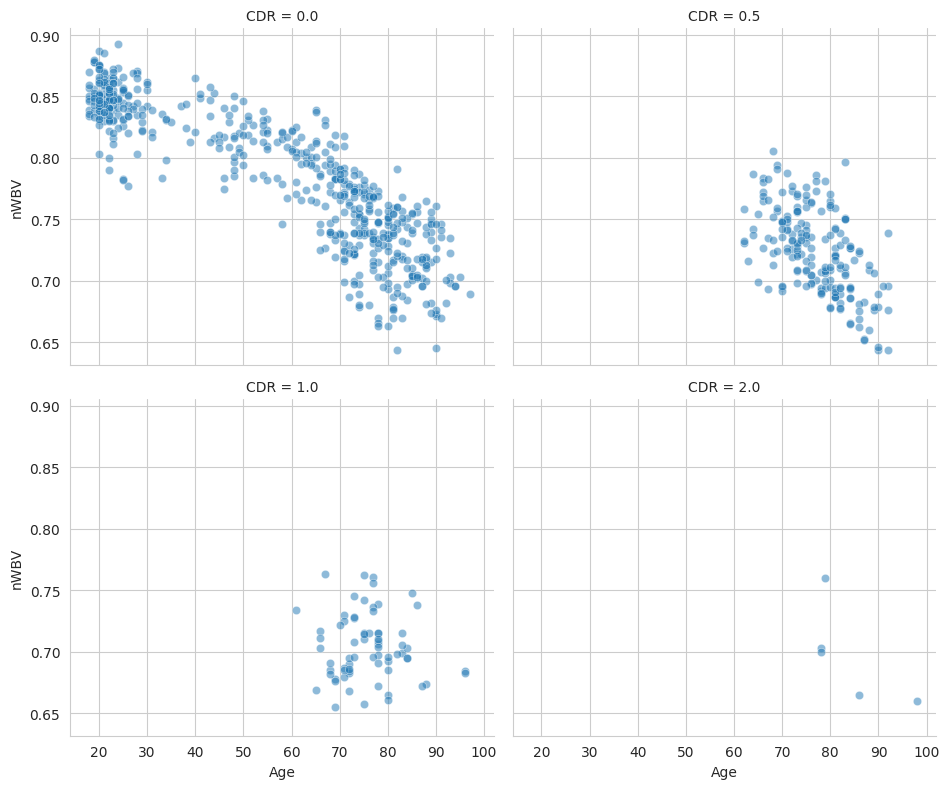

In [38]:
g = sns.FacetGrid(df, col="CDR", height=4, aspect=1.2)
g.map(sns.scatterplot, "Age", "nWBV", alpha=0.6)
g = sns.FacetGrid(df, col="CDR", col_wrap=2, height=4, aspect=1.2)
g.map(sns.scatterplot, "Age", "nWBV", alpha=0.5)

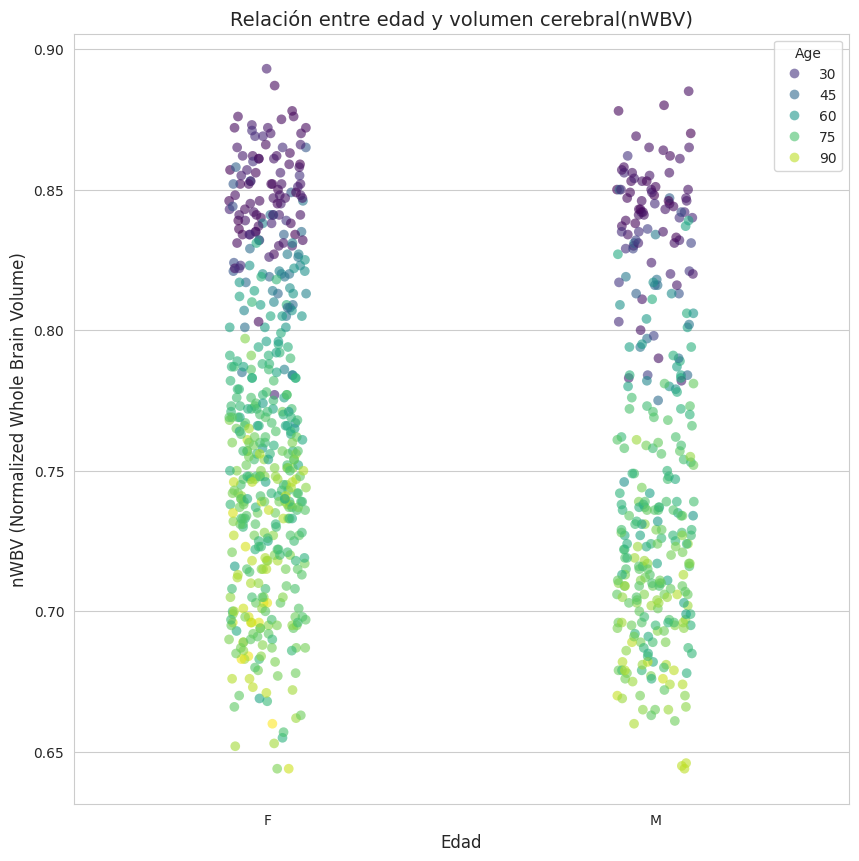

In [39]:
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")
df['Sex2'] = df['Sex'].map({0: 'F', 1: 'M'})
df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='Sex2', y='nWBV', data=df, 
              hue='Age', legend=True,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre edad y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

In [40]:
df_60 = df[df['Age'] > 60]
df_60_9 = df_60[df_60['Age'] < 70]

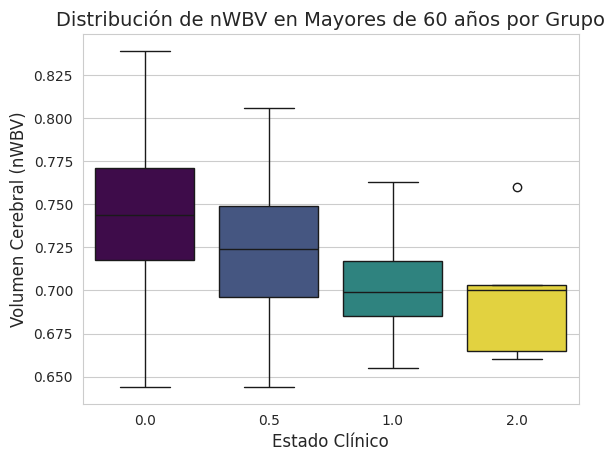

In [41]:
sns.boxplot(x='CDR', y='nWBV', data=df_60, hue='CDR', legend=False,palette='viridis')
plt.title('Distribución de nWBV en Mayores de 60 años por Grupo', fontsize=14)
plt.xlabel('Estado Clínico', fontsize=12)
plt.ylabel('Volumen Cerebral (nWBV)', fontsize=12)
plt.show()

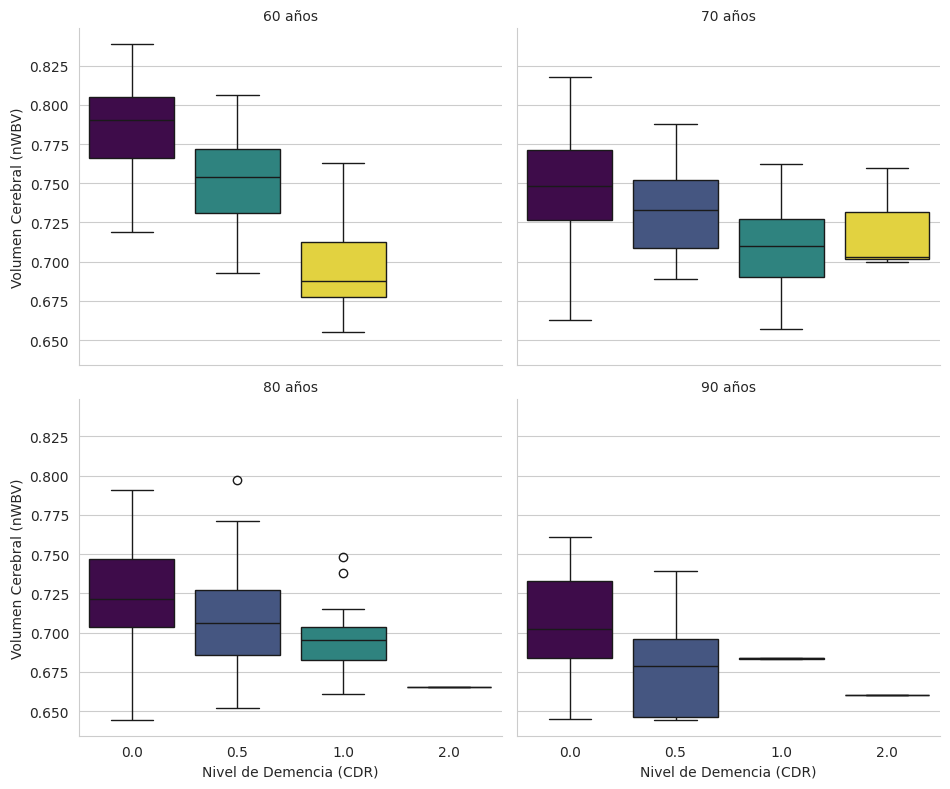

In [42]:

orden_cdr = [0, 0.5, 1, 2]
g = sns.FacetGrid(df_60, col="Decade", col_wrap=2, height=4, aspect=1.2)
g.map_dataframe(sns.boxplot, x="CDR", y="nWBV", hue="CDR", 
                order=orden_cdr, palette='viridis', dodge=False)

g.set_axis_labels("Nivel de Demencia (CDR)", "Volumen Cerebral (nWBV)")
g.set_titles("{col_name} años") 
g.fig.tight_layout()

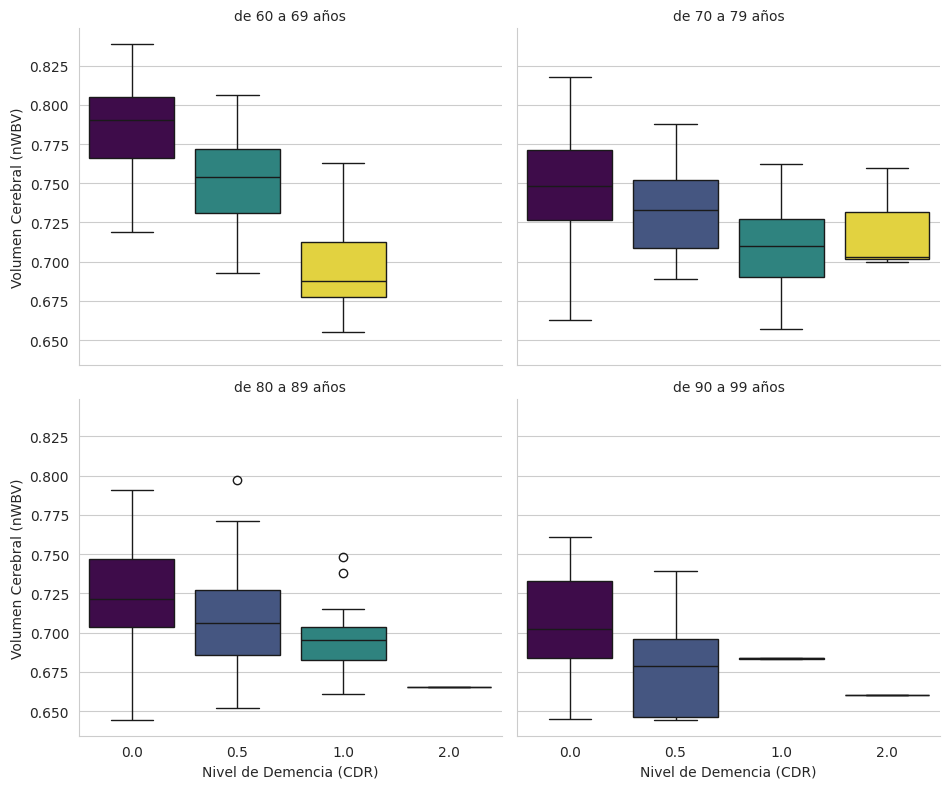

In [43]:
df_60['Decade_Label'] = df_60['Decade'].apply(lambda x: f"de {int(x)} a {int(x)+9}")
orden_decadas = ["de 60 a 69", "de 70 a 79", "de 80 a 89", "de 90 a 99"]
orden_cdr = [0, 0.5, 1, 2]

# 2. Configurar el FacetGrid con 'col_order'
g = sns.FacetGrid(df_60, 
                  col="Decade_Label", 
                  col_wrap=2, 
                  height=4, 
                  aspect=1.2,
                  col_order=orden_decadas) 

# 3. Mapear el boxplot
g.map_dataframe(sns.boxplot, x="CDR", y="nWBV", hue="CDR", 
                order=orden_cdr, palette='viridis', dodge=False)

# 4. Ajustes finales de rotulación [3]
g.set_axis_labels("Nivel de Demencia (CDR)", "Volumen Cerebral (nWBV)")
g.set_titles("{col_name} años")
g.fig.tight_layout()

plt.show()



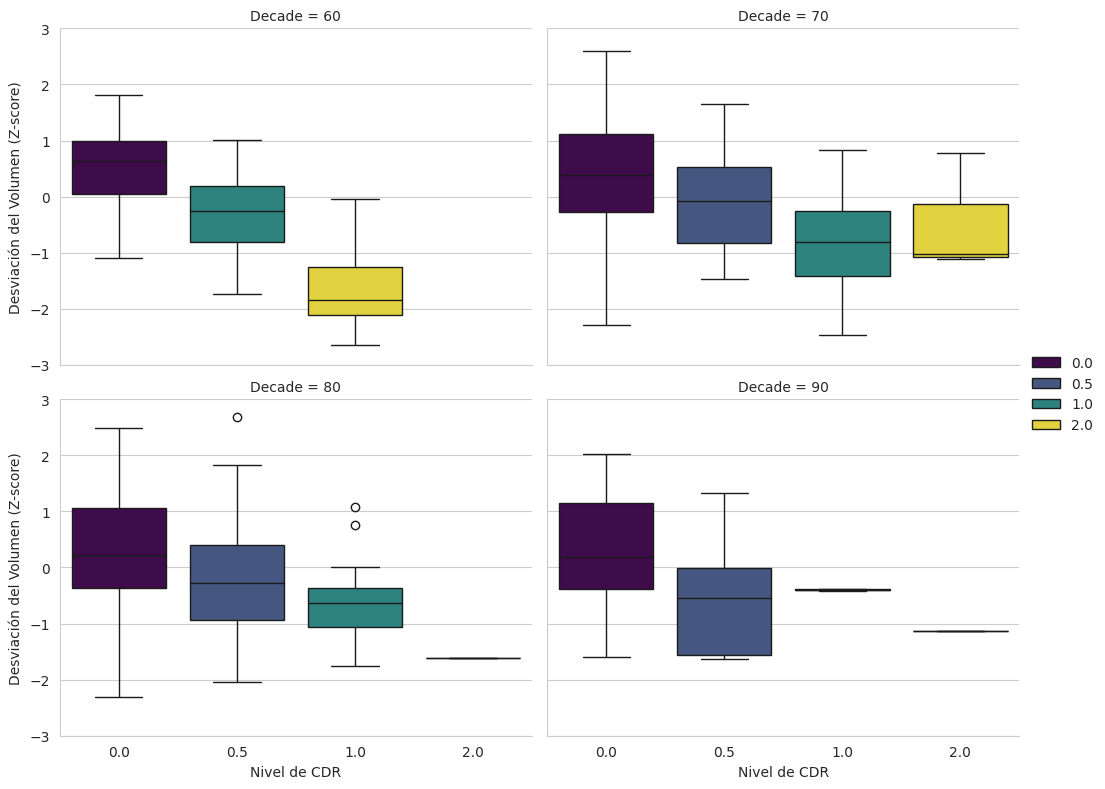

In [44]:
df_60['nWBV_zscore'] = df_60.groupby('Decade')['nWBV'].transform(lambda x: (x - x.mean()) / x.std())
g = sns.FacetGrid(df_60, col="Decade", col_wrap=2, height=4, aspect=1.3)
g.map_dataframe(sns.boxplot, x="CDR", y="nWBV_zscore", hue="CDR", 
                palette='viridis')
g.set(ylim=(-3, 3)) 
g.set_axis_labels("Nivel de CDR", "Desviación del Volumen (Z-score)")
g.add_legend()
plt.show()

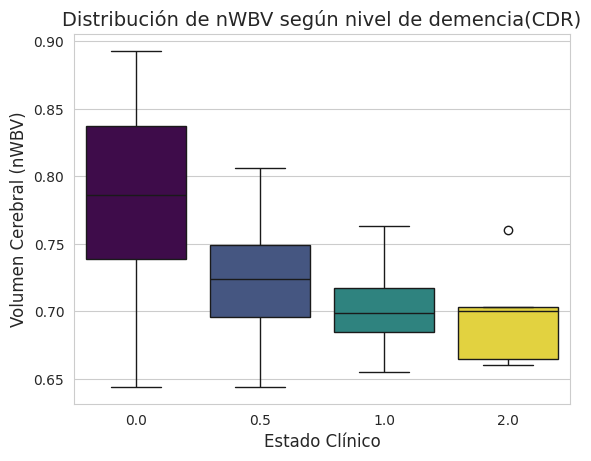

In [45]:
sns.boxplot(x='CDR', y='nWBV', data=df, hue='CDR', legend=False,palette='viridis')
plt.title('Distribución de nWBV según nivel de demencia(CDR)', fontsize=14)
plt.xlabel('Estado Clínico', fontsize=12)
plt.ylabel('Volumen Cerebral (nWBV)', fontsize=12)
plt.show()

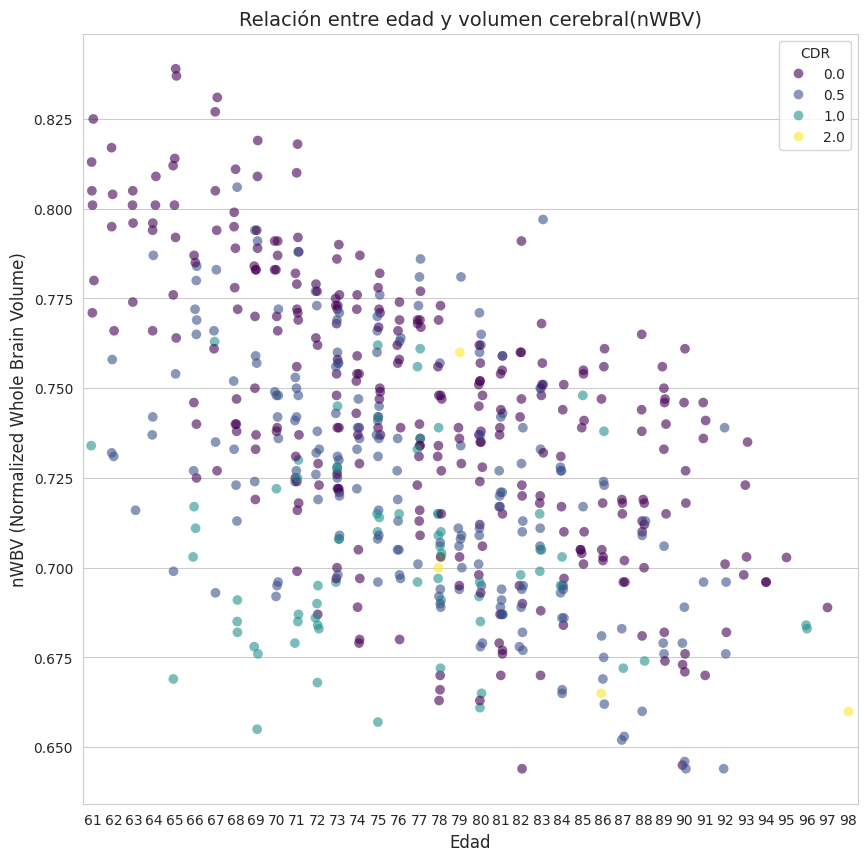

In [46]:
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")
df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='Age', y='nWBV', data=df_60, 
              hue='CDR', legend=True,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre edad y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

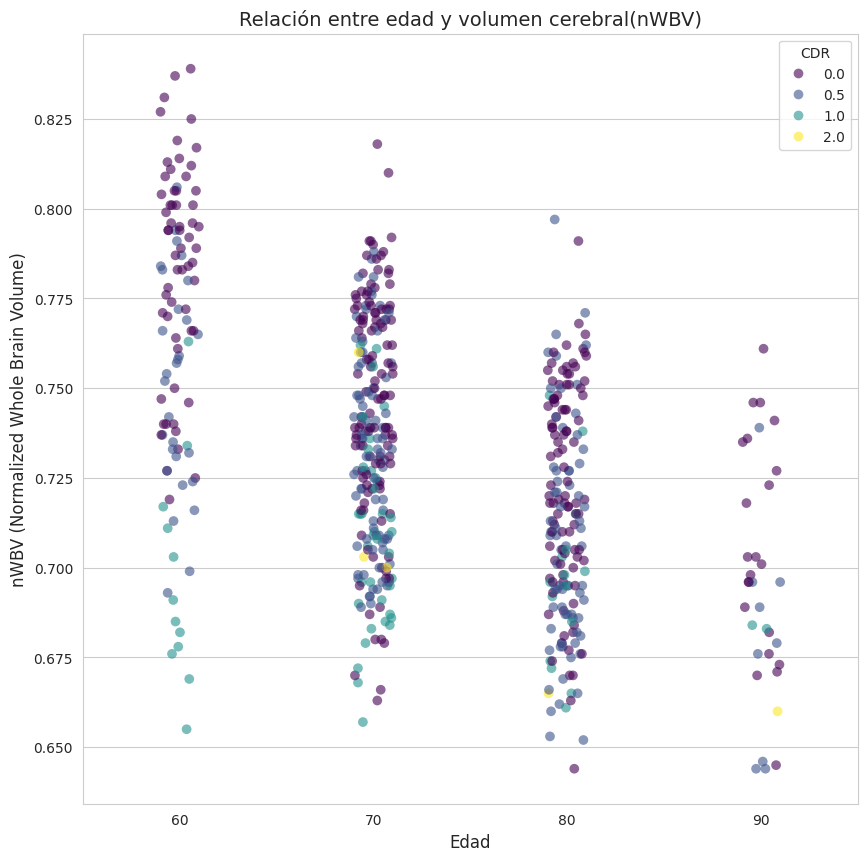

In [47]:
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")
df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='Decade', y='nWBV', data=df_60, 
              hue='CDR', legend=True,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre edad y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

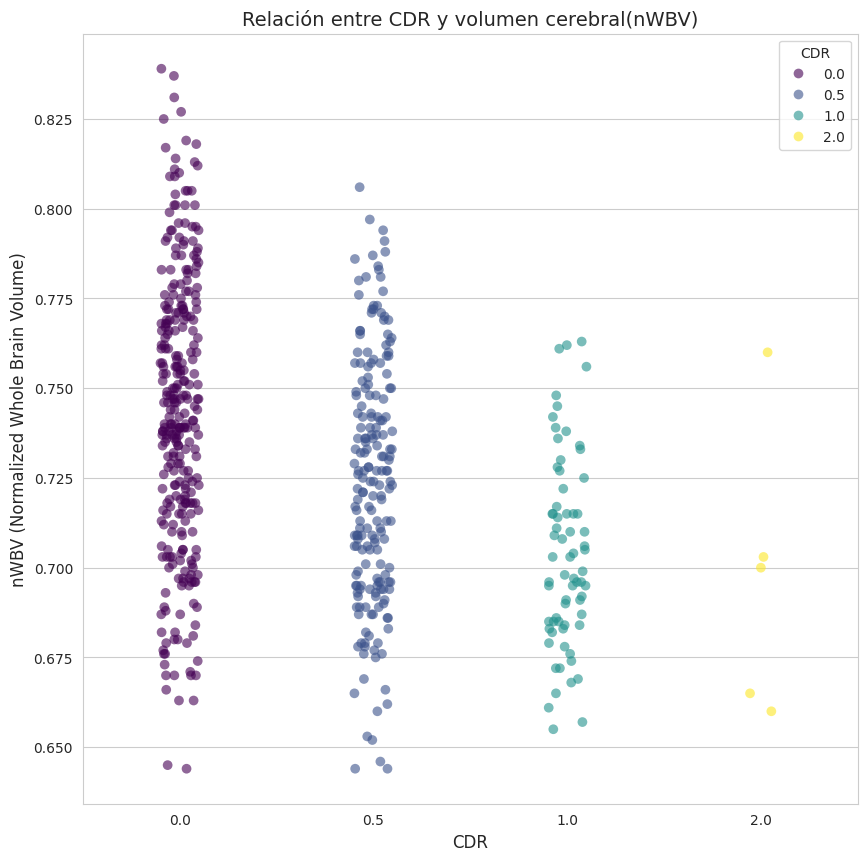

In [48]:
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")
df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='CDR', y='nWBV', data=df_60, 
              hue='CDR', legend=True,palette='viridis', 
              alpha=0.6, size=7, jitter=True)

# 4. Añadir etiquetas y título
plt.title('Relación entre CDR y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('CDR', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

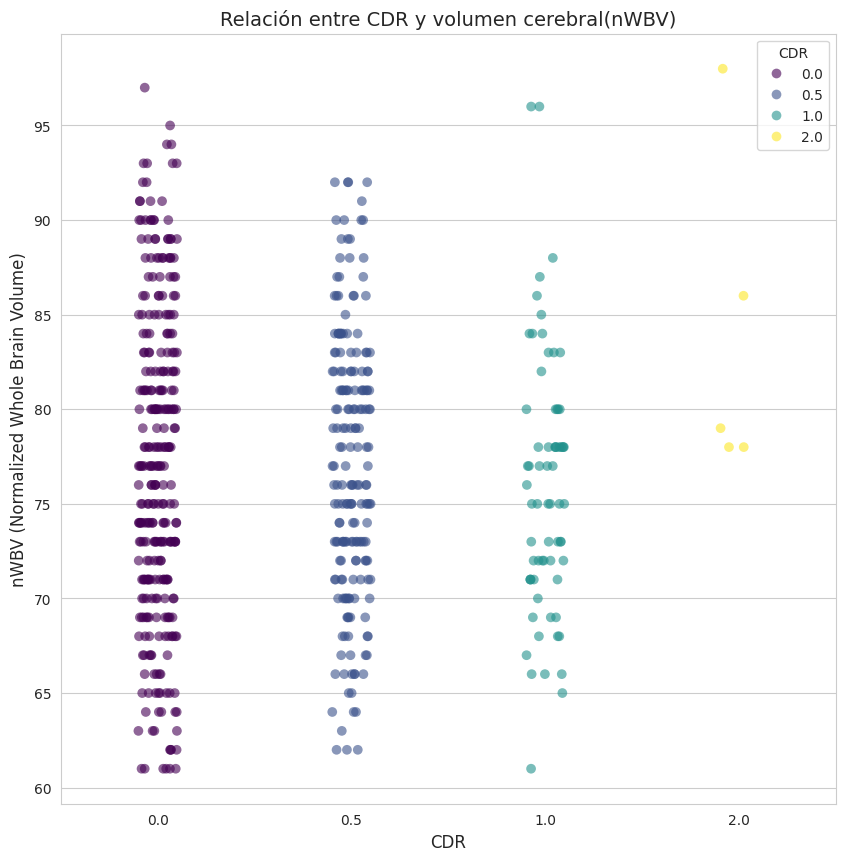

In [49]:
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")
df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='CDR', y='Age', data=df_60, 
              hue='CDR', legend=True,palette='viridis', 
              alpha=0.6, size=7, jitter=True)


plt.title('Relación entre CDR y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('CDR', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

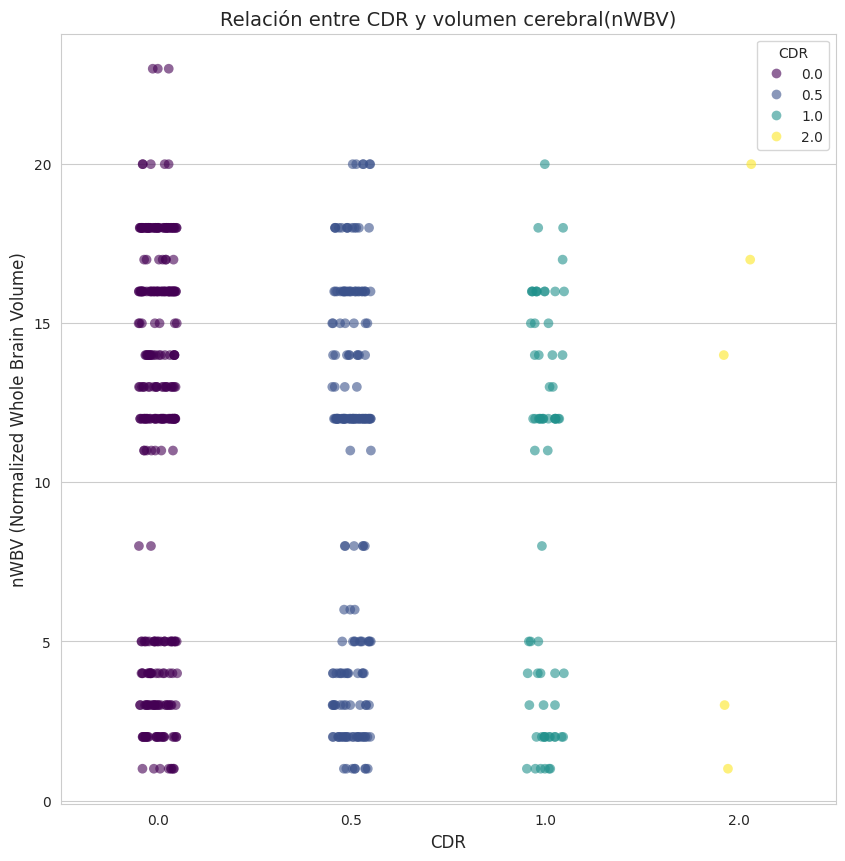

In [50]:
plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")
df['Decade'] = (df['Age'] // 10) * 10
sns.stripplot(x='CDR', y='Educ', data=df_60, 
              hue='CDR', legend=True,palette='viridis', 
              alpha=0.6, size=7, jitter=True)


plt.title('Relación entre CDR y volumen cerebral(nWBV)', fontsize=14)
plt.xlabel('CDR', fontsize=12)
plt.ylabel('nWBV (Normalized Whole Brain Volume)', fontsize=12)

plt.show()

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

In [52]:
conteo_clases = longi['CDR'].value_counts().sort_index()
proporciones = longi['CDR'].value_counts(normalize=True).sort_index() * 100

# Presentación de resultados
print("Distribución de Clases - Set Longitudinal:")
for cdr, total in conteo_clases.items():
    print(f"CDR {cdr}: {total} pacientes ({proporciones[cdr]:.2f}%)")

Distribución de Clases - Set Longitudinal:
CDR 0.0: 206 pacientes (55.23%)
CDR 0.5: 123 pacientes (32.98%)
CDR 1.0: 41 pacientes (10.99%)
CDR 2.0: 3 pacientes (0.80%)


/tmp/ipykernel_8803/3788892977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CDR', data=longi, palette='viridis')


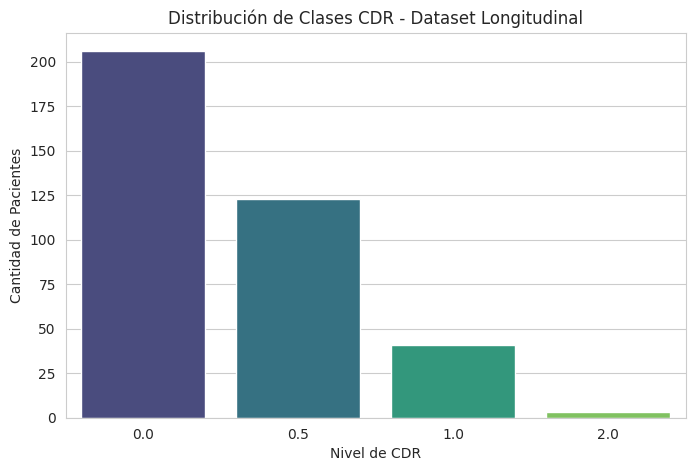

CDR
0.0    55.227882
0.5    32.975871
1.0    10.991957
2.0     0.804290
Name: proportion, dtype: float64


In [53]:
# Visualización del Desbalance de Clases (CDR: 0, 0.5, 1, 2)
plt.figure(figsize=(8, 5))
sns.countplot(x='CDR', data=longi, palette='viridis')
plt.title("Distribución de Clases CDR - Dataset Longitudinal")
plt.xlabel("Nivel de CDR")
plt.ylabel("Cantidad de Pacientes")
plt.show()

# Resumen de desbalance 
print(longi['CDR'].value_counts(normalize=True) * 100)

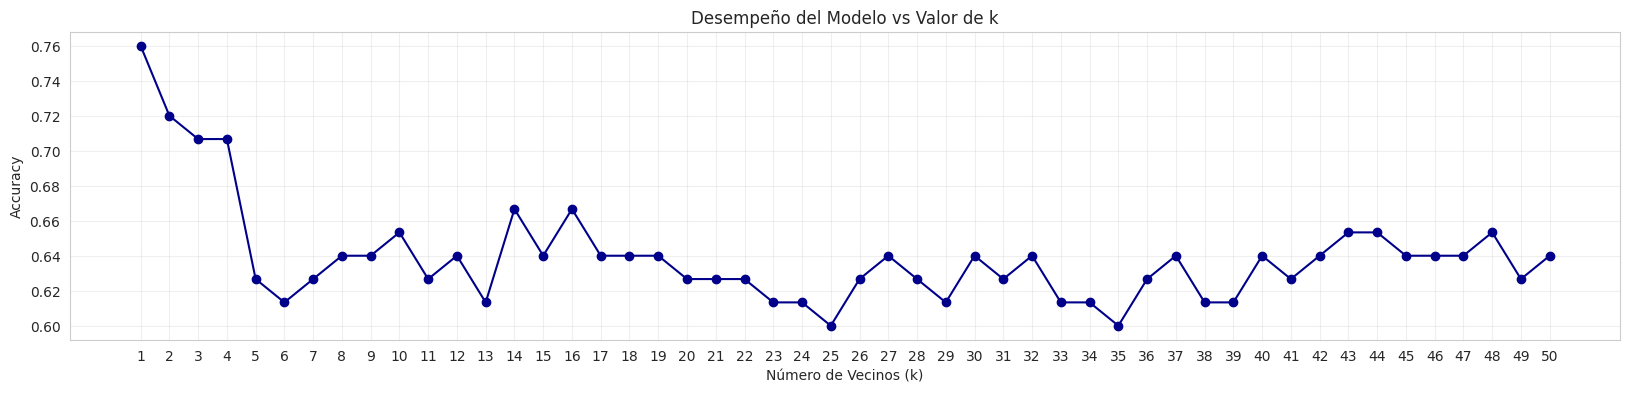

In [54]:
features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = longi[features]
y = longi['CDR'].astype(str)

# Imputación de valores faltantes (SES y MMSE)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Búsqueda de k óptimo
k_values = range(1, 51)
mean_acc = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    # Usamos una partición 80/20 para la curva de validación
    xt, xv, yt, yv = train_test_split(X_imputed, y, test_size=0.2, random_state=42)
    sc = StandardScaler()
    xt_s = sc.fit_transform(xt)
    xv_s = sc.transform(xv)
    knn_temp.fit(xt_s, yt)
    mean_acc.append(accuracy_score(yv, knn_temp.predict(xv_s)))

plt.figure(figsize=(20, 4))
plt.plot(k_values, mean_acc, marker='o', color='darkblue')
plt.title("Desempeño del Modelo vs Valor de k")
plt.xlabel("Número de Vecinos (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

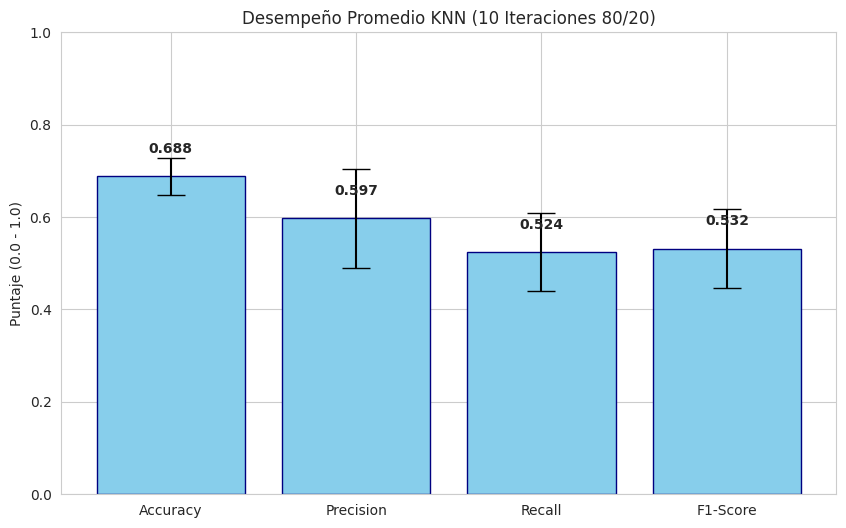

In [55]:
# Diccionario para almacenar métricas de las 10 iteraciones
metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

for i in range(10):
    # Partición independiente
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=i)
    
    # Escalamiento (Vital para KNN por basarse en distancias)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Entrenamiento con k=5
    knn_final = KNeighborsClassifier(n_neighbors=4)
    knn_final.fit(X_train_s, y_train)
    y_pred = knn_final.predict(X_test_s)
    
    # Cálculo de métricas (promedio 'macro' por desbalance y multiclase)
    metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['Precision'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    metrics['Recall'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    metrics['F1-Score'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))

# Visualización de Métricas con Error (Media ± DE)
labels = list(metrics.keys())
means = [np.mean(metrics[m]) for m in labels]
stds = [np.std(metrics[m]) for m in labels]

plt.figure(figsize=(10, 6))
plt.bar(labels, means, yerr=stds, capsize=10, color='skyblue', edgecolor='navy')
plt.title("Desempeño Promedio KNN (10 Iteraciones 80/20)")
plt.ylabel("Puntaje (0.0 - 1.0)")
plt.ylim(0, 1)
for i, v in enumerate(means):
    plt.text(i, v + 0.05, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

In [56]:
cm = confusion_matrix(y_test, y_pred, labels=['0.0', '0.5', '1.0', '2.0'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Muy Leve', 'Leve', 'Modera'])

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusión - Detección de Demencia (Longitudinal)")
plt.show()

# Cálculo de Tasa de Falsos Positivos (FPR) simplificada para Multiclase
# Se calcula como (Falsos Positivos Totales / Negativos Reales Totales)
fp = cm.sum(axis=0) - np.diag(cm)  
fn = cm.sum(axis=1) - np.diag(cm)
tp = np.diag(cm)
tn = cm.sum() - (fp + fn + tp)

fpr = fp / (fp + tn)
print(f"Tasa de Falsos Positivos promedio por clase: {np.mean(fpr):.4f}")


NameError: name 'confusion_matrix' is not defined

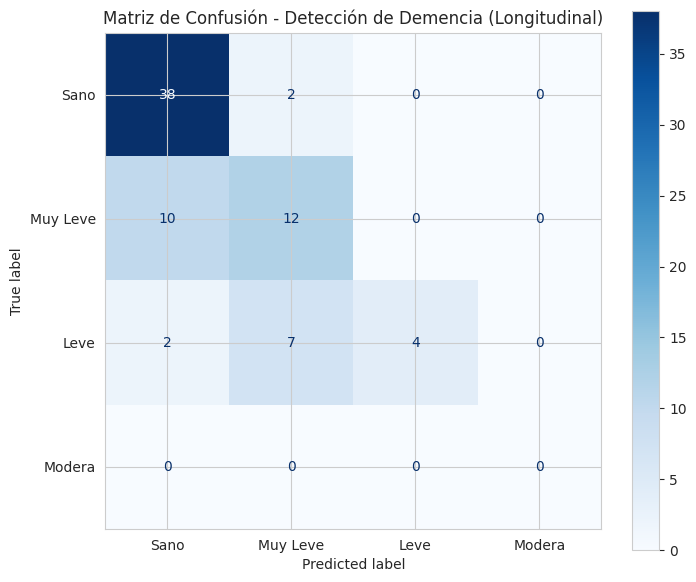

Tasa de Falsos Positivos promedio por clase: 0.1282


In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=['0.0', '0.5', '1.0', '2.0'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Muy Leve', 'Leve', 'Modera'])

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusión - Detección de Demencia (Longitudinal)")
plt.show()

# Cálculo de Tasa de Falsos Positivos (FPR) simplificada para Multiclase
# Se calcula como (Falsos Positivos Totales / Negativos Reales Totales)
fp = cm.sum(axis=0) - np.diag(cm)  
fn = cm.sum(axis=1) - np.diag(cm)
tp = np.diag(cm)
tn = cm.sum() - (fp + fn + tp)

fpr = fp / (fp + tn)
print(f"Tasa de Falsos Positivos promedio por clase: {np.mean(fpr):.4f}")


In [ ]:
# Prueba con k=1 (Probable Sobreajuste)
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, knn1.predict(X_train_scaled))
test_acc = accuracy_score(y_test, knn1.predict(X_test_scaled))

print(f"k=1 -> Entrenamiento: {train_acc:.4f}, Prueba: {test_acc:.4f}")
# Si train_acc >> test_acc, es sobreajuste según la guía [1].

k=1 -> Entrenamiento: 1.0000, Prueba: 0.8267


In [ ]:
# Diccionario para almacenar los resultados del testeo
test_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

for i in range(10):
    # Paso A: Partición 80/20 con semilla (random_state) variable
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=i)
    
    # Paso B: Escalamiento (Ajustado solo en entrenamiento para evitar filtración) [5]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Paso C: Entrenamiento del modelo (ejemplo con k=5)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    
    # Paso D: Predicción sobre el set de prueba (el testeo real)
    y_pred = knn.predict(X_test_scaled)
    
    # Paso E: Registro de métricas
    test_metrics['acc'].append(accuracy_score(y_test, y_pred))
    # Usamos 'macro' por el desbalance de clases (CDR 2 tiene muy pocos ejemplos) [2, 6]
    test_metrics['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    test_metrics['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    test_metrics['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))

In [ ]:
print(f"--- RESULTADOS FINALES DEL TESTEO (Longitudinal) ---")
print(f"Accuracy:  {np.mean(test_metrics['acc']):.4f} ± {np.std(test_metrics['acc']):.4f}")
print(f"Precision: {np.mean(test_metrics['prec']):.4f} ± {np.std(test_metrics['prec']):.4f}")
print(f"Recall:    {np.mean(test_metrics['rec']):.4f} ± {np.std(test_metrics['rec']):.4f}")
print(f"F1-Score:  {np.mean(test_metrics['f1']):.4f} ± {np.std(test_metrics['f1']):.4f}")


--- RESULTADOS FINALES DEL TESTEO (Longitudinal) ---
Accuracy:  0.6747 ± 0.0414
Precision: 0.5983 ± 0.1097
Recall:    0.5427 ± 0.0942
F1-Score:  0.5480 ± 0.0931


In [ ]:
from sklearn.metrics import classification_report, f1_score
# Escalado: Vital para KNN para que atributos como eTIV no dominen al nWBV [2, 8]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Evaluación con métricas robustas (Macro) [7]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Reporte detallado por clase (Punto 13 de la guía) [4, 7]
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

         0.0       0.66      0.85      0.74        39
         0.5       0.65      0.43      0.52        30
         1.0       0.60      0.50      0.55         6

    accuracy                           0.65        75
   macro avg       0.64      0.59      0.60        75
weighted avg       0.65      0.65      0.64        75

